Using Linear Regression model that has been created for training and prediction purpose

**Work flow of a linear regression model:**

Step 1: Set Learning rate and number of iterations; Initiate random weight and bias value

Step 2: Build Linear Regression equation (y = wx+b)

Step 3: Find the "y_pred" values for the given x values for the corresponding weight and bias

Step 4: Check the loss function for the parameter values. (Difference between "y_pred" and "true y")

Step 5: Update the parameter values using Gradient Descent (new weight and bias values)

Step 6: Step 3, 4 & 5 are repeated till we get minimum loss function value

Finally we will get the best model (best weight and bias value) as it has minimum loss function value

In [45]:
#importing libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from src.linear_regression import Linear_Regression # Importing the manually created linear regression model
from src.evaluation import(sum_squared_error,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r_squared)

In [6]:
salary_data = pd.read_csv("../data/salary_data.csv")

In [7]:
salary_data.head()

,YearsExperience,Salary
0,1.1,413000
1,1.3,370000
2,1.5,469000
3,1.7,495000
4,2.0,392000


In [8]:
salary_data.tail()

,YearsExperience,Salary
25,7.6,968000
26,8.0,1044000
27,8.5,1081000
28,9.0,1129000
29,9.5,1174000


In [9]:
salary_data.shape

(30, 2)

In [10]:
salary_data.isnull().sum() # Checking for the missing values

YearsExperience    0
Salary             0
dtype: int64

In [11]:
salary_data.duplicated().sum() # Checking for the duplicate entries

np.int64(0)

In [12]:
# Splitting the dependent and independent variables, Years of experience - Indpendent & Salary - Dependent

X = salary_data.iloc[:,:-1].values
Y = salary_data.iloc[:,1].values

In [20]:
X.shape

(30, 1)

In [21]:
Y.shape

(30,)

In [30]:
# Splitting the dataset into train and test dataset

X_train,X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.33, random_state=2)

In [31]:
X_train.shape

(20, 1)

In [32]:
Y_train.shape

(20,)

In [33]:
# Training the linear regression model created from scratch

model = Linear_Regression(learning_rate=0.02, no_of_iterations=1000) # Assigning the manually created regression model
model.fit(X_train,Y_train)

In [34]:
#Printing the parameter of the trained model

print("Weight = ",model.weight[0])
print("Bias = ",model.bias)

Weight =  94396.08050336827
Bias =  280705.57434284204


In [35]:
# Predicting the salary from the test data

test_prediction = model.predict(X_test)
print(test_prediction)

[403420.47899722 384541.26289655 705487.936608   582773.03195362
 894280.09761474 847082.05736305 941478.13786642 516695.77560126
 441178.91119857 865961.27346373]


**Evaluating the model**

Text(0.5, 1.0, 'Salary vs Years of Experience')

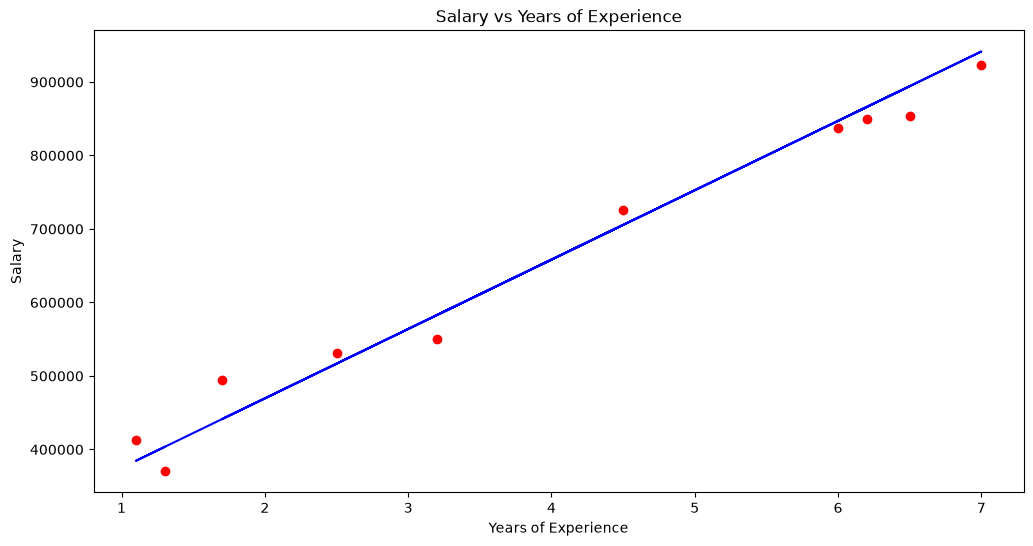

In [39]:
# Visualizing the predicted and actual values
plt.figure(figsize=(12, 6))
plt.scatter(X_test,Y_test, color = 'red')
plt.plot(X_test,test_prediction,color = 'blue')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Years of Experience")

In [46]:
print("SSE :", sum_squared_error(Y_test, test_prediction))
print("MSE :", mean_squared_error(Y_test, test_prediction))
print("RMSE:", root_mean_squared_error(Y_test, test_prediction))
print("MAE :", mean_absolute_error(Y_test, test_prediction))
print("R²  :", r_squared(Y_test, test_prediction))

SSE : 8824138796.771317
MSE : 882413879.6771317
RMSE: 29705.45201940431
MAE : 26709.119095439695
R²  : 0.9767645185328717


**Conclusion**

Based on the evaluation metrics from the test set, your from-scratch Linear Regression model performs strongly on this dataset.

SSE = 8,824,138,796.77 — this is the total squared error across the test observations. SSE is mainly useful as an aggregate error measure and is not very intuitive because it is expressed in squared salary units.

MSE = 882,413,879.68 — this is the average squared prediction error. Like SSE, its units are squared salary units, so it is less directly interpretable.

RMSE = 29,705.45 — predictions have an error magnitude on the order of ₹29.7K on the test set. Because RMSE is in the same units as salary, this is one of the most interpretable metrics here.

MAE = 26,709.12 — the average absolute difference between the actual and predicted salaries is approximately ₹26.7K.

R² = 0.9768 — the model accounts for approximately 97.68% of the observed variation in salary on this test set, relative to a mean-prediction baseline.

**Overall interpretation**

The combination of a high R² and relatively low RMSE/MAE indicates that the model captures the strong linear relationship between years of experience and salary in this dataset. The fact that RMSE (~₹29.7K) is somewhat higher than MAE (~₹26.7K) also indicates that some prediction errors are larger than the typical absolute error, which is expected because RMSE gives greater weight to larger errors.

Most importantly, this result demonstrates that your manually implemented gradient-descent linear regression is successfully learning the relationship from the data without using sklearn's regression implementation.

One qualification: 97.68% R² should not be interpreted as 97.68% prediction accuracy, and these results are specific to your particular test split and dataset. A different train/test split could produce different metrics.